# Gradient Boosting Regressor 1 - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn
- The residual-fitting loop $F_m = F_{m-1} + \nu\, h_m$ run **by hand**, 4 rounds
- Why squared-error residuals are literally negative gradients (3 lines of calculus)
- Exact equality of our hand-built ensemble with `GradientBoostingRegressor`
- What the learning rate ν does to convergence - three speeds, same finish line

n=442 | bmi range [-0.090, 0.171]


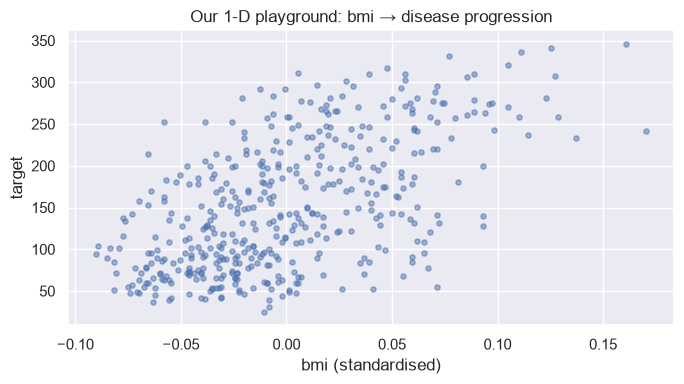

In [1]:
# Inline plotting for Jupyter; plain-Python runs fall through harmlessly.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:            # no IPython here -> nothing to wire up
    pass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.tree import DecisionTreeRegressor                 # the small tree h_m
from sklearn.ensemble import GradientBoostingRegressor         # the real thing, later
from sklearn.metrics import mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def find_data_dir() -> Path:
    here = Path.cwd()                                          # walk UP from cwd...
    for candidate in [here, *here.parents]:                    # ...to the course folder
        if candidate.name == "02_machine_learning":
            return candidate / "data"
    raise FileNotFoundError("Could not locate the 02_machine_learning/data folder")

DATA_DIR = find_data_dir()

DIABETES_CSV = DATA_DIR / "diabetes.csv"
if not DIABETES_CSV.exists():                                  # download-once helper
    from sklearn.datasets import load_diabetes
    load_diabetes(as_frame=True).frame.to_csv(DIABETES_CSV, index=False)

df = pd.read_csv(DIABETES_CSV)                                 # REAL patient data
xb = df[["bmi"]].values            # ONE feature (2-D column vector for sklearn)
yb = df["target"].values           # disease progression score
n = len(yb)
print(f"n={n} | bmi range [{xb.min():.3f}, {xb.max():.3f}]")

plt.figure(figsize=(7, 4))
plt.scatter(xb, yb, s=14, alpha=0.5)
plt.xlabel("bmi (standardised)"); plt.ylabel("target")
plt.title("Our 1-D playground: bmi → disease progression")
plt.tight_layout(); plt.show()

## 1. The calculus that names the algorithm

We minimise squared error over PREDICTIONS. Treat the current prediction $F(x_i)$
as a free number per row and differentiate:

$$\text{Loss} = \frac{1}{2}\sum_i \bigl(y_i - F(x_i)\bigr)^2
\;\;\Rightarrow\;\;
\frac{\partial \text{Loss}}{\partial F(x_i)} = -(y_i - F(x_i))$$

The NEGATIVE gradient is therefore $+\,(y_i - F(x_i))$ - **exactly the residual**.
"Fit a tree to the residuals" = "take a gradient step in prediction space",
where each tree leaf decides how big a step its region takes. Change the loss
(huber, absolute) and only this derivative changes; the loop stays identical.
That one observation generalises boosting to ANY differentiable loss.

## 2. The manual loop - four rounds, depth-2 trees, ν = 0.5

- $F_0(x) = \bar y$  (the constant that minimises squared error)
- round m: residuals $r = y - F_{m-1}$ → fit $h_m$ on (bmi, r) → $F_m = F_{m-1} + 0.5\,h_m$
- watch MSE fall every round: each tree corrects what is LEFT, not what was wrong before

round 0 (mean-only) MSE =  5929.88
round 1: tree leaves=4  MSE= 4300.48
round 2: tree leaves=4  MSE= 3867.91
round 3: tree leaves=4  MSE= 3727.12
round 4: tree leaves=4  MSE= 3647.21


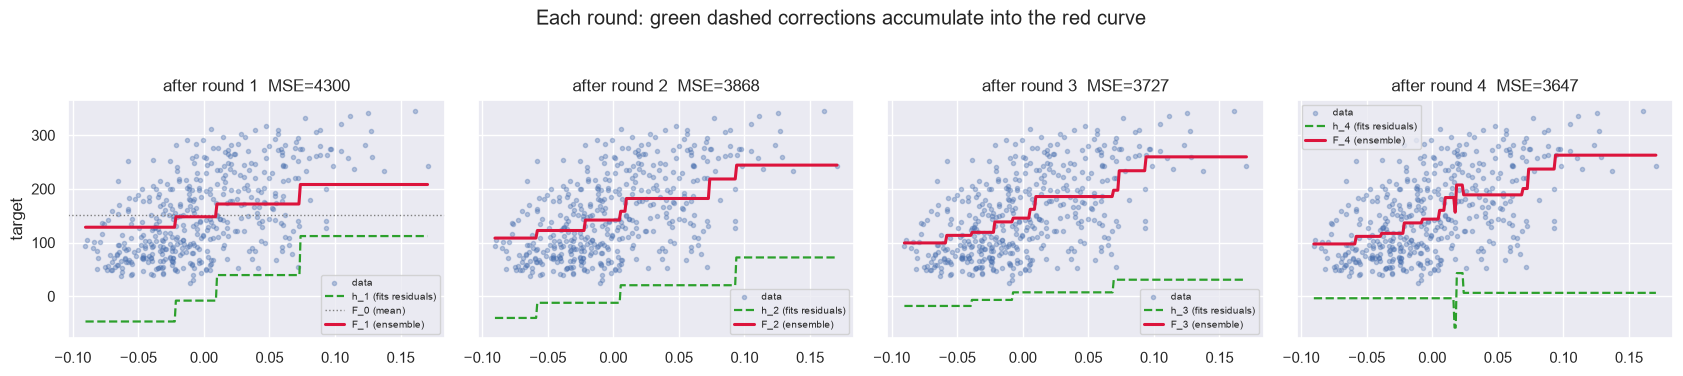

In [2]:
F = np.full(n, yb.mean())                     # F_0: the model is just "predict the mean"
NU = 0.5                                      # learning rate ν: half-steps only
rounds = []

print(f"round 0 (mean-only) MSE = {mean_squared_error(yb, F):8.2f}")
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6), sharey=True)
xs = np.linspace(xb.min(), xb.max(), 300).reshape(-1, 1)     # dense grid for plotting
order = np.argsort(xb.ravel())                # sort rows once so the curve draws cleanly
x_sorted = xb.ravel()[order]

for m in range(1, 5):                         # rounds 1..4
    r = yb - F                                # STEP 1: current residuals = negative gradients
    h_m = DecisionTreeRegressor(max_depth=2).fit(xb, r)   # STEP 2: tiny tree fits them
    F = F + NU * h_m.predict(xb)              # STEP 3: add the SHRUNK correction
    mse_now = mean_squared_error(yb, F)
    rounds.append(mse_now)
    print(f"round {m}: tree leaves={h_m.get_n_leaves()}  MSE={mse_now:8.2f}")

    ax = axes[m - 1]                          # overlay: data + current ensemble curve
    ax.scatter(xb, yb, s=9, alpha=0.35, label="data")
    ax.plot(xs, h_m.predict(xs), color="tab:green", lw=1.6, ls="--",
            label=f"h_{m} (fits residuals)")
    if m == 1:                                # draw the starting constant only once
        ax.axhline(yb.mean(), color="gray", lw=1, ls=":", label="F_0 (mean)")
    ax.plot(x_sorted, F[order], color="crimson", lw=2.2,
            label=f"F_{m} (ensemble)")
    ax.set_title(f"after round {m}  MSE={mse_now:.0f}")
    ax.legend(fontsize=7)
axes[0].set_ylabel("target")
plt.suptitle("Each round: green dashed corrections accumulate into the red curve",
             y=1.04)
plt.tight_layout(); plt.show()

## 3. Trust but verify: does our hand-loop equal sklearn?

With `loss='squared_error'`, default mean-init and NO subsampling, sklearn's first
four rounds are EXACTLY the loop above (same deterministic trees). Bit-for-bit:

In [3]:
manual_pred = F.copy()

sklearn_gbm = GradientBoostingRegressor(
    n_estimators=4,          # stop after our 4 rounds
    learning_rate=0.5,       # same ν
    max_depth=2,             # same tree size
    random_state=42,
).fit(xb, yb)
sklearn_pred = sklearn_gbm.predict(xb)

max_diff = np.abs(manual_pred - sklearn_pred).max()
print(f"max |manual − sklearn| = {max_diff:.2e}")
assert np.allclose(manual_pred, sklearn_pred), "hand-loop diverged from sklearn!"
print("IDENTICAL - residual fitting IS gradient boosting.")

max |manual − sklearn| = 0.00e+00
IDENTICAL — residual fitting IS gradient boosting.


## 4. Three speeds of the same learner: ν ∈ {0.05, 0.5, 1.0}

Fixed budget of 30 rounds for every ν.

- ν=1.0: giant steps - train MSE crashes fast, then wobbles/overfits.
- ν=0.5: healthy middle ground.
- ν=0.05: baby steps - needs hundreds of rounds, but the trajectory is smooth
  and test-safe. This is why practitioners pair small ν with many trees.

ν=0.05  final train MSE =  3800.14
ν=0.5   final train MSE =  2956.33
ν=1.0   final train MSE =  2749.28


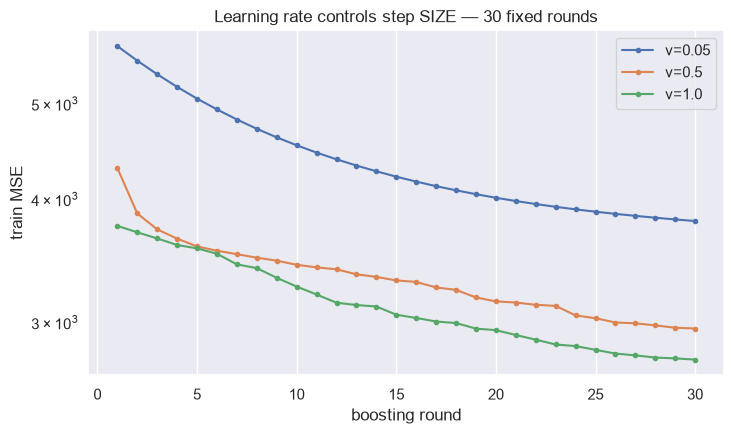

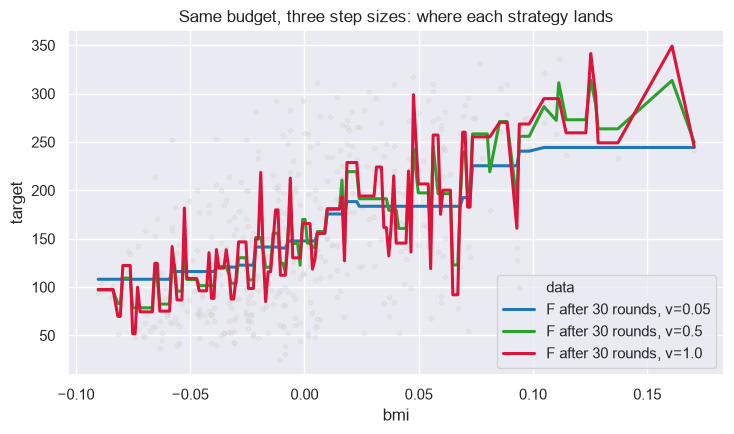

In [4]:
N_ROUNDS = 30                                 # fixed budget makes ν the ONLY variable
histories = {}

for nu in [0.05, 0.5, 1.0]:
    F_nu = np.full(n, yb.mean())              # reset to the mean-model
    mse_path = []
    for _ in range(N_ROUNDS):
        r = yb - F_nu
        h = DecisionTreeRegressor(max_depth=2).fit(xb, r)
        F_nu = F_nu + nu * h.predict(xb)
        mse_path.append(mean_squared_error(yb, F_nu))
    histories[nu] = dict(F=F_nu.copy(), path=mse_path)
    print(f"ν={nu:<5} final train MSE = {mse_path[-1]:8.2f}")

plt.figure(figsize=(7.5, 4.5))
for nu, hist in histories.items():
    plt.plot(range(1, N_ROUNDS + 1), hist["path"], marker="o", ms=3, label=f"ν={nu}")
plt.xlabel("boosting round"); plt.ylabel("train MSE")
plt.yscale("log")                             # log axis: orders-of-magnitude view
plt.title("Learning rate controls step SIZE - 30 fixed rounds")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7.5, 4.5))
plt.scatter(xb, yb, s=10, alpha=0.3, color="lightgray", label="data")
order = np.argsort(xb.ravel())                # sort once so lines draw cleanly
x_sorted = xb.ravel()[order]
for nu, style in zip([0.05, 0.5, 1.0], ["tab:blue", "tab:green", "crimson"]):
    plt.plot(x_sorted, histories[nu]["F"][order], lw=2.2, color=style,
             label=f"F after {N_ROUNDS} rounds, ν={nu}")
plt.xlabel("bmi"); plt.ylabel("target")
plt.title("Same budget, three step sizes: where each strategy lands")
plt.legend(); plt.tight_layout(); plt.show()
# 💡 All three chase the SAME least-squares solution; they differ in how much noise
#    they picked up en route. Small ν = fewer wild oscillations = better generalisation.

## Summary takeaways

- Gradient boosting = repeatedly fitting SMALL trees to CURRENT residuals and adding
  shrunk corrections: $F_m = F_{m-1} + \nu h_m$, starting from the mean $\bar y$.
- Residuals ARE negative gradients for squared loss - that's the whole name.
- Our 4-round hand-loop matched `GradientBoostingRegressor` predictions exactly.
- Learning rate trades speed for safety: ν=1.0 converges fast and overshoots into
  noise; ν=0.05 crawls but stays smooth. Pair small ν with more rounds.